# Błędy numeryczne

Zagadnienia:
* Reprezentacja liczb w komputerze:
    * Zapis stałoprzecinkowy,
    * Zapis zmiennoprzecinkowy (standard IEEE 754),
* Błędy numeryczne:
    * Błąd względny i bezwzględny.
    * Błąd zaokrąglenia (ang. *round-off error*).
    * Błąd obcięcia (ang. *truncation error*).
    * Błędy związane z przyjętym sposobem rozwiązywania.

## Błąd względny i bezwzględny

***Zadanie 1.***  
Liczbę $\textrm{e}$ możemy zdefiniować jako $\sum\limits_{n=0}^{\infty} \frac{1}{n!}$. Oblicz błąd względny i bezwzględny aproksymacji liczby $\textrm{e}$ poprzez $\textrm{e}^{*}$ w przypadku gdy:  
* $\textrm{e}_1^{*}=\sum\limits_{n=0}^{5} \frac{1}{n!}$    

* $\textrm{e}_2^{*}=\sum\limits_{n=0}^{10} \frac{1}{n!}$  

* $\textrm{e}_3^{*}=\sum\limits_{n=0}^{20} \frac{1}{n!}$  

In [1]:
import math

def calculate_e_approx(n_terms):
    return sum(math.factorial(n)**-1 for n in range(n_terms + 1))

e_true = math.e
ns = [5, 10, 20]

for n in ns:
    e_approx = calculate_e_approx(n)
    abs_err = abs(e_true - e_approx)
    rel_err = abs_err / abs(e_true)
    print(f"n={n}: e*={e_approx:.15f}, Błąd bezwzględny: {abs_err:.2e}, Błąd względny: {rel_err:.2e}")

n=5: e*=2.716666666666667, Błąd bezwzględny: 1.62e-03, Błąd względny: 5.94e-04
n=10: e*=2.718281801146385, Błąd bezwzględny: 2.73e-08, Błąd względny: 1.00e-08
n=20: e*=2.718281828459045, Błąd bezwzględny: 0.00e+00, Błąd względny: 0.00e+00


## Zapis zmiennoprzecinkowy

**Uwaga**: Używane tu pojęcie **cecha** ma inne znaczenie, niż poznane być może w szkole – skrótowo: „część całkowita”. Dlatego poniżej dodawane jest inne określenie – „wykładnik”.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sys

In [ ]:
print(np.finfo(float))
eps = np.finfo(float).eps

***Zadanie 2.***


a) Wstaw dowolną wartość do liczby x, np. 0.1. Które liczby mają tę samą mantysę, a które tę samą cechę (wykładnik)? Sprawdź wypisując ich wartości w formacie hex.


**Uwaga:** Do odczytania liczby w formacie szesnastkowym możesz wykorzystać funkcję:

In [ ]:
1.25.hex()

In [ ]:
5000.0.hex()

lub

In [ ]:
import struct
def double_to_hex(f):
    print(hex(struct.unpack('<Q', struct.pack('<d', f))[0]))

In [ ]:
double_to_hex(1.25)

Zamianę w drugą stronę można przeprowadzić za pomocą funkcji *int*

In [ ]:
int('3ff', 16)

In [ ]:
x = 1.25
print(f"1.25: {1.25.hex()}") 
print(f"2.5:  {2.5.hex()}")  
print(f"1.3:  {1.3.hex()}")  

1.25: 0x1.4000000000000p+0
2.5:  0x1.4000000000000p+1
1.3:  0x1.4cccccccccccdp+0




b) Porównaj zapis liczb 0.1, 0.2 i 0.3 w formacie zmiennoprzecinkowym.

* Czy można przewidzieć, czy suma 0.1 + 0.2 będzie reprezentowana dokładnie tak samo jak liczba 0.3?
* Jaki będzie wynik porównania tej sumy z liczbą 0.3 i konsekwencje użycia warunku równościowego / nierównościowego w pętli?



In [10]:
0.1 + 0.2 == 0.3
#Przy użyciu takiego porównania w pętli, może się ona stać nieskończona

False

c) Przyjmijmy, że „skrótowe” określenie *liczba dokładnie reprezentowana* oznacza liczbę, która jest reprezentowana w formacie zmiennoprzecinkowym dokładnie, tzn. bez konieczności zaokrąglania.
* Ile jest liczb dokładnie reprezentowanych w przedziale $[1, 2)$?
* Zaobserwuj (z pomocą formatu hex) jakie wartości mają bity w polu mantysy w przypadku liczby 1.0.
* Jaką liczbę trzeba dodać do 1.0, aby tylko na najmłodszej pozycji pola mantysy pojawiło się 1?
* Czy wyżej otrzymana suma jest najmniejszą liczbą dokładnie reprezentowana, spośród liczb większych od 1?
* Jak przypuszczasz, jakie wartości będą miały poszczególne bity mantysy w przypadku największej liczby dokładnie reprezentowanej, której cecha (wykładnik) jest równy 0? Sprawdź, czy tak jest rzeczywiście – wpisując wartość tej liczby (jaka to jest wartość?).


In [ ]:
#W przedziale [1, 2) jest ich 2^{52} (tyle wynosi liczba bitów mantysy w double).
# Liczba 1.0 w hex: 0x1.0000000000000p+0. Mantysa to same zera (bit ukryty "1" przed przecinkiem nie jest zapisywany).
# Aby zmienić najmłodszy bit, dodajemy epsilon maszynowy ( 2.22 x 10^{-16}).
# Największa liczba z wykładnikiem 0 (przedział [1, 2)) to taka, która ma same jedynki w mantysie. Jej wartość to 2 - epsilon.

d) Oblicz długości przedziałów, do których należą wszystkie liczby mające cechę (wykładnik) równy: 0, 1, 2, 5, -1, -3.

* Czy w każdym z tych przedziałów jest tyle samo liczb dokładnie reprezentowanych? Jeżeli nie, to ile w każdym z nich?
* Jaka jest odległość między dwoma sąsiednimi liczbami dokładnie reprezentowanymi (odległość, czyli różnica ich wartości) w każdym z tych przedziałów?
* Jaki jest maksymalny błąd bezwzględny zaokrąglenia w każdym z tych przedziałów?
* Jaki jest maksymalny błąd względny zaokrąglenia w każdym z tych przedziałów?





In [12]:
import numpy as np

def analyze_exponent_intervals(exponents):
    # Liczba bitów mantysy dla float64 (double precision) to 52
    mantissa_bits = 52
    
    print(f"{'Cecha (E)':<10} | {'Przedział':<18} | {'Długość':<10} | {'Krok (odległość)':<15} | {'Max błąd bezwzględny'}")
    print("-" * 85)
    
    for e in exponents:
        # 1. Obliczanie przedziału [2^e, 2^(e+1))
        start = 2.0**e
        end = 2.0**(e+1)
        interval_range = end - start
        
        # 2. Odległość między liczbami (krok)
        # Każdy przedział jest dzielony na 2^52 części
        step = interval_range / (2**mantissa_bits)
        
        # 3. Maksymalny błąd bezwzględny
        # Największy błąd to połowa odległości między sąsiednimi liczbami
        max_abs_err = step / 2
        
        # 4. Maksymalny błąd względny
        # Najgorszy przypadek jest na początku przedziału
        max_rel_err = max_abs_err / start
        
        print(f"{e:<10} | [{start:<7}, {end:<7}) | {interval_range:<10} | {step:<15.2e} | {max_abs_err:.2e}")

# Wykładniki do sprawdzenia
cechy = [0, 1, 2, 5, -1, -3]
analyze_exponent_intervals(cechy)

# Odpowiedzi na pytania teoretyczne z zadania:
print("\n--- Odpowiedzi na pytania ---")
print("1. Czy w każdym przedziale jest tyle samo liczb? TAK, w każdym jest 2^52 liczb.")
print("2. Jaka jest odległość (krok)? Wynosi 2^(E-52).")
print("3. Błąd względny? Jest w przybliżeniu stały i wynosi 2^-53 (ok. 1.11e-16).")

Cecha (E)  | Przedział          | Długość    | Krok (odległość) | Max błąd bezwzględny
-------------------------------------------------------------------------------------
0          | [1.0    , 2.0    ) | 1.0        | 2.22e-16        | 1.11e-16
1          | [2.0    , 4.0    ) | 2.0        | 4.44e-16        | 2.22e-16
2          | [4.0    , 8.0    ) | 4.0        | 8.88e-16        | 4.44e-16
5          | [32.0   , 64.0   ) | 32.0       | 7.11e-15        | 3.55e-15
-1         | [0.5    , 1.0    ) | 0.5        | 1.11e-16        | 5.55e-17
-3         | [0.125  , 0.25   ) | 0.125      | 2.78e-17        | 1.39e-17

--- Odpowiedzi na pytania ---
1. Czy w każdym przedziale jest tyle samo liczb? TAK, w każdym jest 2^52 liczb.
2. Jaka jest odległość (krok)? Wynosi 2^(E-52).
3. Błąd względny? Jest w przybliżeniu stały i wynosi 2^-53 (ok. 1.11e-16).


***Zadanie 3.***

Spójrz na poniższe zjawiska, zastanów się nad ich przyczynami.

***Problem skali***

Jaki wynika da poniższy kod:

In [11]:
a = 1.0
b = 0.0000000000000000000000001
c = a + b
print(f'{c:.17f}')

1.00000000000000000


W tym przykładzie jest błąd zaokrąglenia, ponieważ liczba wykracza poza zakres bitów mantysy

***Problem reprezentacji w zapisie binarnym*** 

In [13]:
if 0.1+0.2==0.3:
    print("True")
else:
    print("False")

False


In [14]:
suma = 0
for i in range(0,100):
    suma += 0.1
print(f'{suma:.15f}')

9.999999999999980


**Zadanie 4.**

Niech:
* $a=0.3$
* $b=10^{-13}$
* $c=a-b$
* $d=a-c$

Czy $b$ i $d$ są sobie równe w sensie analitycznym? Co z przypadkiem numerycznym? Zdefiniuj odpowiednie zmienne i porównaj wyniki. Porównaj szesnastkowe i dziesietne reprezentacje zmiennych `b` i `d`. Ile cyfr w reprezentacji `d` możemy uznać za wiarygodne?

In [16]:
a = 0.3
b = 10^(-13)
c = a - b
d = a - c
print(f"b: {b:.20f}")
print(f"d: {d:.20f}")
print(f"Równe? {b == d}")

b: -7.00000000000000000000
d: -7.00000000000000000000
Równe? True


**Zadanie 5.**

Rozważmy macierz kwadratową:
$$ A=\left[\begin{array}{ccc}
\sqrt{2} & \frac{1}{7}\\
\pi\sqrt{2} &\frac{\pi}{7}\\
\end{array}\right]
$$
* Czy jest to macierz osobliwa? Jak to sprawdzić?
* Oblicz wyznacznik tej macierzy w sposób analityczny i numeryczny (`np.linalg.det`). Czy otrzymałeś te same wartości? Czy wyniki obliczeń numerycznych prowadzą do poprawnej odpowiedzi na pierwsze pytanie? Jakie może to mieć skutki?

In [18]:
import numpy as np

# Definicja macierzy
A = np.array([[np.sqrt(2), 1/7], [np.pi*np.sqrt(2), np.pi/7]])

# Obliczenia
det_analityczny = 0
det_numeryczny = np.linalg.det(A)

print(f"Wyznacznik analityczny: {det_analityczny}")
print(f"Wyznacznik numeryczny: {det_numeryczny:.20f}")
print(f"Czy są identyczne? {det_analityczny == det_numeryczny}")

Wyznacznik analityczny: 0
Wyznacznik numeryczny: 0.00000000000000000000
Czy są identyczne? True


Macież jest osobliwa, ponieważ jej wiersze są liniowo zależne

**Zadanie 6.**

Jedną z metod rozwiązywania równań nieliniowych jest metoda Newtona. Metoda ta powtarza obliczenia, aż spełniony nie będzie warunek stopu. Jeżeli spełnione są odpowiednie założenia to metoda ta zbiega do rozwiązania. Załóżmy, że warunki są spełnione i rozważmy funkcję $f(x)=cos(x)-x$. Poniżej znajdziesz implementację metody Newtona, w której brakuje warunku stopu. Spróbuj go uzupełnić. Warunek powinien być spełniony w momencie, w którym chcemy zakończyć działanie procedury.

Z matematycznego punktu widzenia znajdujemy się w zerze, jeżeli kolejne przybliżenia uzyskane z metody Newtona nie różnią się od siebie (np. dwa ostatnie). Zaimplementuj taki warunek i sprawdź, czy program zatrzyma się. Czy taki warunek stopu jest bezpieczny i można go stosować uniwersalnie? Jak można go poprawić?

In [25]:
def newton(f, f_prim, x_0):
    x_prev = x_0
    while True:
        x_n=x_prev-(f(x_prev)/f_prim(x_prev))
        print(f'x_0={x_n}')
        double_to_hex(x_n)
        
        if abs(x_n - x_prev) < 1e-12: # Zastąp True swoim warunkiem stopu
            return x_n
        else:
            x_prev=x_n

In [23]:
import numpy as np

def f(x):
    return np.cos(x) - x

def f_prim(x):
    return -np.sin(x) - 1

**Zadanie domowe**  

Dany jest ciąg:  
  
$G(p)=\cfrac{1}{p}\left[10^{p}\left(1+p\pi^{*} \cdot 10^{-p}\right)-10^{p}\right],\ p=1,2,3,\dots,n $,
w którym $\pi^{*}$ jest przybliżeniem liczby $\pi$ z dokładnością do 15 miejsc po przecinku.
  
Stwórz funkcję, która umożliwi obliczenie $n$ pierwszych wyrazów tego ciągu i zwróci je w postaci wektora (do przybliżenia wartości $\pi$ możesz wykorzystać funkcję *[round](https://numpy.org/doc/stable/reference/generated/numpy.round_.html)*). Oblicz błąd bezwzględny i błąd względny otrzymanych wyników. Przedstaw rezultaty na wykresie w zależności od $n$. Wartości błędów przedstaw w skali logarytmicznej (funkcja *plt.semilogy()*).

Przeanalizuj rozwiązanie i odpowiedz na następujące pytania:  
* Czy w obliczeniach analitycznych wartość $G(p)$ zależy od $p$?
* Jak zmienia się błąd w zależności od $n$? O czym to świadczy?
* Z jakim/jakimi rodzajami błędu mamy do czynienie?


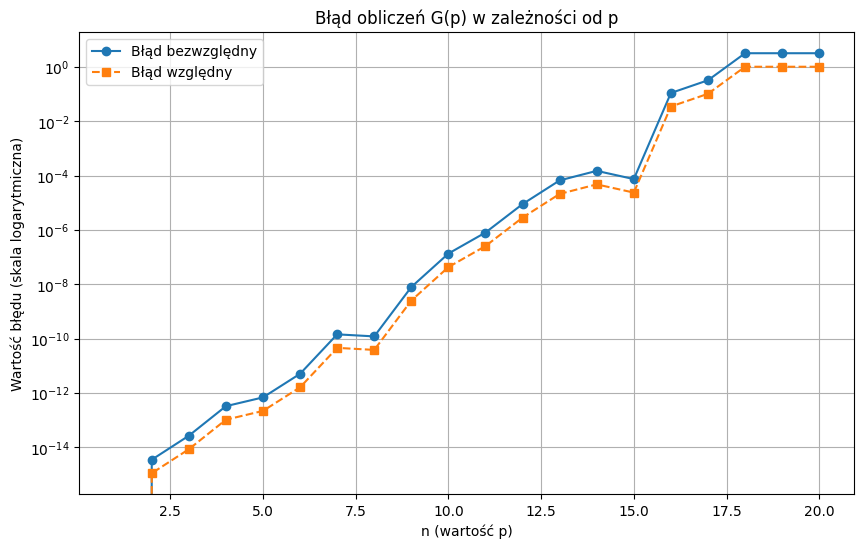

In [27]:
import numpy as np
import matplotlib.pyplot as plt

def oblicz_G(n):
    # pi* to przybliżenie pi do 15 miejsc po przecinku
    pi_star = np.round(np.pi, 15)
    p_values = np.arange(1, n + 1)
    
    # Obliczenie ciągu G(p)
    # G(p) = 1/p * [10^p * (1 + p * pi_star * 10^-p) - 10^p]
    G_p = (1/p_values) * (10.0**p_values * (1 + p_values * pi_star * 10.0**-p_values) - 10.0**p_values)
    
    # Błędy względem wartości oczekiwanej pi_star
    abs_err = np.abs(G_p - pi_star)
    rel_err = abs_err / np.abs(pi_star)
    
    return p_values, G_p, abs_err, rel_err

# Parametry i wykonanie
n = 20
p, G, b_bezwzgl, b_wzgl = oblicz_G(n)

# Wykres
plt.figure(figsize=(10, 6))
plt.semilogy(p, b_bezwzgl, 'o-', label='Błąd bezwzględny')
plt.semilogy(p, b_wzgl, 's--', label='Błąd względny')
plt.xlabel('n (wartość p)')
plt.ylabel('Wartość błędu (skala logarytmiczna)')
plt.title('Błąd obliczeń G(p) w zależności od p')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()